# Monte Carlo Simulation for Portfolio Market Risk Estimation

This project applies Monte Carlo simulation to estimate portfolio market risk.

The goal is to generate a large number of possible future return scenarios and use them to evaluate potential losses. Based on the simulated loss distribution, Value-at-Risk (VaR) and Expected Shortfall (ES) are computed.

This project demonstrates how simulation-based methods can be used in financial risk management to assess uncertainty and tail risk.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [3]:
data = pd.read_csv("financial_data.csv", index_col="Date", parse_dates=True)
data.head()

,SPY,QQQ,IWM,EFA
Date,,,,
2018-01-01,251.244669,152.738733,120.229072,70.331818
2018-01-02,250.985103,152.597571,120.752297,70.403704
2018-01-03,252.594765,152.682277,120.787910,70.443003
2018-01-04,256.326131,154.099618,117.988983,68.783209
2018-01-05,255.829411,154.602139,118.229131,69.314725


## Data Preparation

We compute log returns from the price series and construct an equally weighted portfolio.

The portfolio return series will serve as the basis for parameter estimation and simulation.

In [4]:
returns = np.log(data / data.shift(1)).dropna()

weights = np.array([0.25, 0.25, 0.25, 0.25])
portfolio_returns = returns.dot(weights)

portfolio_returns.head()

Date
2018-01-02    0.000851
2018-01-03    0.001950
2018-01-04   -0.005846
2018-01-05    0.002762
2018-01-08    0.009307
dtype: float64

## Parameter Estimation

To simulate future portfolio returns, we estimate the mean and volatility of historical portfolio returns.

These parameters define the probability model used in the Monte Carlo simulation.

In [5]:
mu = portfolio_returns.mean()
sigma = portfolio_returns.std()

print("Estimated mean:", mu)
print("Estimated volatility:", sigma)

Estimated mean: 0.00016663083911549114
Estimated volatility: 0.0056670333443994605


## Monte Carlo Simulation

We simulate a large number of possible future portfolio returns based on the estimated mean and volatility.

This creates a simulated distribution of future outcomes, which can then be used to estimate risk measures.

In [6]:
n_simulations = 10000

simulated_returns = np.random.normal(mu, sigma, n_simulations)

simulated_returns[:10]

array([ 3.07038879e-03, -4.64460150e-03,  5.50845382e-03,  2.26574278e-03,
        2.12643981e-03,  2.42212519e-03,  1.60351839e-03,  3.64821838e-05,
        1.34756577e-03, -3.29876150e-04])

## Simulated Loss Distribution

The simulated returns are transformed into losses by taking the negative of the return.

This allows direct estimation of Value-at-Risk and Expected Shortfall from the simulated loss distribution.

In [8]:
simulated_losses = -simulated_returns

simulated_losses[:10]

array([-3.07038879e-03,  4.64460150e-03, -5.50845382e-03, -2.26574278e-03,
       -2.12643981e-03, -2.42212519e-03, -1.60351839e-03, -3.64821838e-05,
       -1.34756577e-03,  3.29876150e-04])

## Monte Carlo Value-at-Risk and Expected Shortfall

Based on the simulated loss distribution, we estimate:
- Value-at-Risk (VaR): the loss threshold exceeded only with small probability
- Expected Shortfall (ES): the average loss beyond the VaR threshold

In [9]:
mc_var_95 = np.quantile(simulated_losses, 0.95)
mc_var_99 = np.quantile(simulated_losses, 0.99)

mc_es_95 = simulated_losses[simulated_losses >= mc_var_95].mean()
mc_es_99 = simulated_losses[simulated_losses >= mc_var_99].mean()

print("Monte Carlo VaR 95%:", mc_var_95)
print("Monte Carlo VaR 99%:", mc_var_99)
print("Monte Carlo ES 95%:", mc_es_95)
print("Monte Carlo ES 99%:", mc_es_99)

Monte Carlo VaR 95%: 0.009300756190972639
Monte Carlo VaR 99%: 0.013213148861259483
Monte Carlo ES 95%: 0.011721673913466932
Monte Carlo ES 99%: 0.015154382390666877


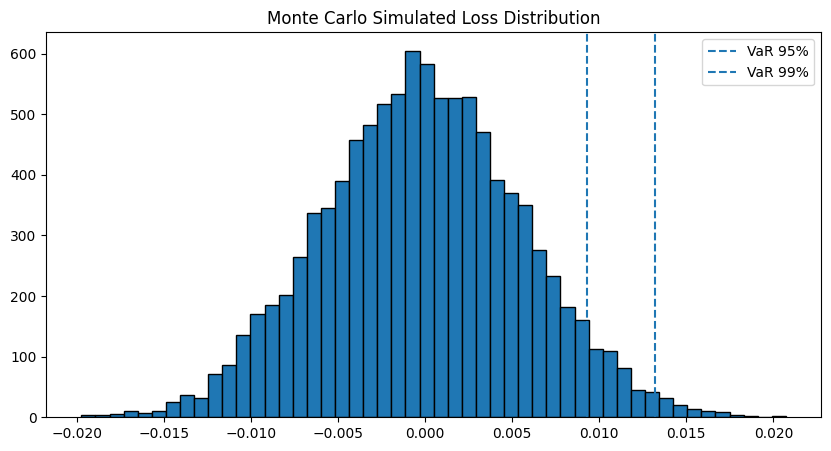

In [10]:
plt.figure(figsize=(10,5))
plt.hist(simulated_losses, bins=50, edgecolor="black")
plt.axvline(mc_var_95, linestyle="--", label="VaR 95%")
plt.axvline(mc_var_99, linestyle="--", label="VaR 99%")
plt.title("Monte Carlo Simulated Loss Distribution")
plt.legend()
plt.show()

## Comparison with Historical Simulation

To better understand the effect of simulation-based modeling, the Monte Carlo results can be compared with risk estimates obtained from historical returns.

This highlights differences between model-based and data-driven approaches.

In [12]:
hist_var_95 = -np.quantile(portfolio_returns, 0.05)
hist_var_99 = -np.quantile(portfolio_returns, 0.01)

print("Historical VaR 95%:", hist_var_95)
print("Historical VaR 99%:", hist_var_99)

print("Monte Carlo VaR 95%:", mc_var_95)
print("Monte Carlo VaR 99%:", mc_var_99)

Historical VaR 95%: 0.009069097585457613
Historical VaR 99%: 0.013052238724690078
Monte Carlo VaR 95%: 0.009300756190972639
Monte Carlo VaR 99%: 0.013213148861259483


# Conclusion

This project used Monte Carlo simulation to estimate portfolio market risk.

By simulating a large number of future return scenarios, it was possible to construct a loss distribution and estimate Value-at-Risk (VaR) and Expected Shortfall (ES).

Compared with historical simulation, Monte Carlo methods provide a flexible framework for modeling future uncertainty. However, the quality of results depends strongly on the assumptions of the underlying model, especially the assumed return distribution.